# Agents 

### Agents 사용 예시
에이전트는 LLM이 스스로 판단하여 필요한 도구(Tool)를 선택하고 실행하는 구조를 말합니다.<br />
과거에는 프롬프트 엔지니어링 기법(ReAct 등)에 의존해 텍스트를 파싱하는 방식으로 에이전트를 구현했으나, 이는 파싱 에러에 취약했습니다.<br />
최신 에이전트는 LLM 제조사가 모델 자체에 내장한 Native Function Calling(네이티브 함수 호출) 기능을 활용합니다.<br />
개발자가 도구의 목록과 명세(Spec)를 API 파라미터로 전달하면, 모델이 알아서 구조화된 JSON 형태로 사용할 도구와 매개변수를 정확하게 지정해 줍니다.<br />
이를 통해 에이전트의 속도와 안정성이 비약적으로 향상되었습니다.<br />
랭체인(LangChain)에서는 이를 반영하여 Native Function Calling에 최적화된 에이전트 생성 함수(create_agent)를 제공합니다.

## 1. ReAct 방식

프롬프트 엔지니어링 기반의 에이전트 개념인 ReAct(Reasoning + Acting) 방식을 알아보겠습니다.<br />
<br />
ReAct는 LLM이 생각(Reasoning) 과 행동(Acting) 을 반복하면서 문제를 해결하는 대표적인 에이전트 기법입니다.<br />
과거의 LangChain에서는 Thought → Action → Observation → Final Answer 형식의 ReAct 프롬프트와 AgentExecutor를 이용하여 문자열을 파싱하고 Tool을 실행하는 방식으로 에이전트를 구현했습니다.<br />
<br />
그러나 LangChain 1.x에서는 create_react_agent()를 사용하는 방식이 권장<br />
또한 Gemini와 같은 최신 LLM은 Native Function Calling을 지원하므로, 개발자가 Thought, Action, Observation 형식의 프롬프트를 직접 작성하거나 문자열을 파싱할 필요가 없습니다.<br />
<br />
즉, ReAct의 핵심 개념(추론 → 행동 → 관찰 → 반복)은 그대로 유지되지만, 구현 방식은 텍스트 파싱 기반에서 Function Calling 기반으로 발전했습니다.

In [7]:
# 1. 라이브러리 설치
%!pip install -U --force-reinstall langchain langchain-core langchain-community langchain-google-genai

UsageError: Line magic function `%!pip` not found.


In [8]:
# 2. API KEY
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

In [25]:
# 3.Tool 만들기
import subprocess
from langchain_core.tools import tool

@tool
def terminal(command: str) -> str:
    """
    Linux 명령어를 실행합니다.
    """
    result = subprocess.run(
        command,
        shell=True,
        capture_output=True,
        text=True
    )

    return result.stdout

In [26]:
# 4.LLM
# from langchain_google_genai import ChatGoogleGenerativeAI

# llm = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
#     temperature=0
# )
from langchain_ollama import ChatOllama
llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.7
)

In [27]:
# 5.ReAct Prompt 작성
from langchain_core.prompts import PromptTemplate

template = """
Answer the following questions as best you can.

You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer

Thought: you should always think about what to do

Action: the action to take, should be one of [{tool_names}]

Action Input: the input to the action

Observation: the result of the action

... (this Thought/Action/Action Input/Observation can repeat N times)

Thought: I now know the final answer

Final Answer: the final answer to the original input question


Example

Question: What files are in the sample_data directory?

Thought: I can use the terminal to list the files in the sample_data directory.

Action: terminal

Action Input: data

Observation:
README.md
anscombe.json
mnist_train_small.csv

Thought: I now know the files in the sample_data directory.

Final Answer:
The sample_data directory contains README.md, anscombe.json and mnist_train_small.csv.


Begin!

Question: {input}

Thought:
{agent_scratchpad}
"""

prompt = PromptTemplate.from_template(template)

입력 프롬프트가 ‘Thought:’로 끝났기 때문에 첫 번째 줄은 ‘sample_data 디렉터리의 파일 목록을 나열하기 위해 터미널을 사용할 수 있다’라는 LLM의 생각으로 되어 있습니다.<br /> 
그리고 Action으로 ‘terminal’이 지정돼 있고, Action Input으로 ‘ls sample_data’가 지정되어 있습니다.<br />
랭체인의 Agent는 이 응답 문자열에서 Action과 Action Input의 내용을 정규식으로 추출합니다.<br /> 
그리고 terminal이라는 도구에서 ‘ls sample_data’를 실행하고 싶다는 내용에 따라 실제로 셸에서 ‘ls sample_data’라는 명령을 실행한다.

In [28]:
# 6.Tool 목록
tools = [terminal]

In [29]:
# 7.ReAct Agent 생성
from langchain_classic.agents import create_react_agent

agent = create_react_agent(
    llm=llm,
    tools=tools,
    prompt=prompt
)

In [30]:
# 8.AgentExecutor 생성
from langchain_classic.agents import AgentExecutor

agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True
)

In [31]:
# 9.질문
response = agent_executor.invoke(
    {
        "input":"data 디렉터리에 있는 파일 목록을 알려줘."
    }
)



> Entering new AgentExecutor chain...
I need to list the files in the `data` directory. I can use the terminal for this.

Action: terminal
Action Input: data
Action: terminal
Action Input: data
data 디렉터리에 있는 파일 목록은 다음과 같습니다:
README.md
anscombe.json
mnist_train_small.csv
Final Answer: README.md, anscombe.json, mnist_train_small.csv

> Finished chain.


In [32]:
# 10. 결과 출력
print(response["output"])

README.md, anscombe.json, mnist_train_small.csv


In [ ]:
### Tool을 사용한 또다른 예
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent


# 1.Tool
@tool
def add(a: int, b: int) -> int:
    """
    두 숫자를 더합니다.
    """
    return a + b

# 2.LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
)


# 3.Agent
agent = create_agent(
    model=llm,
    tools=[add],
    system_prompt="당신은 친절한 AI 비서입니다."
)


# 4.질문
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "15와 27을 더해줘."
            }
        ]
    }
)

# 5.결과
print(response["messages"][-1].content)

In [3]:
import subprocess
from langchain_core.tools import tool

# ==========================================
# 3. Tool 만들기
# ==========================================
import re

@tool
def add(numbers: str) -> int:
    """두 수를 더합니다."""

    print("Tool Input:", repr(numbers))

    nums = re.findall(r"-?\d+", numbers)

    if len(nums) != 2:
        raise ValueError(f"입력 오류: {numbers}")

    return int(nums[0]) + int(nums[1])

@tool
def terminal(command: str) -> str:
    """
    Linux 명령어를 실행합니다. 실패 시 에러 메시지를 반환합니다.
    """
    result = subprocess.run(
        command,
        shell=True,
        capture_output=True,
        text=True
    )
    if result.returncode == 0:
        return result.stdout
    else:
        return f"Error: {result.stderr}"

# ==========================================
# 4. LLM 설정
# ==========================================
# from langchain_google_genai import ChatGoogleGenerativeAI

# llm = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
#     temperature=0
# )
from langchain_ollama import ChatOllama
llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.7
)
# ==========================================
# 5. ReAct Prompt 작성
# ==========================================
from langchain_core.prompts import PromptTemplate

template = """Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
{agent_scratchpad}"""

prompt = PromptTemplate.from_template(template)


# ==========================================
# 6. Tool 목록 (add를 리스트에 정상 포함)
# ==========================================
tools = [add, terminal]


# ==========================================
# 7. ReAct Agent 생성 (올바른 패키지 경로)
# ==========================================
from langchain_classic.agents import create_react_agent

agent = create_react_agent(
    llm=llm,
    tools=tools,
    prompt=prompt
)

# ==========================================
# 8. AgentExecutor 생성
# ==========================================
from langchain_classic.agents import AgentExecutor

agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True,
    handle_parsing_errors=True
)

# ==========================================
# 9. 질문 실행 (두 도구를 복합적으로 쓰도록 유도 가능)
# ==========================================
# 예시 1: add 툴 테스트
response = agent_executor.invoke(
    {
        "input": "12345와 67890을 더하면 얼마야?"
    }
)

print(response["output"])



> Entering new AgentExecutor chain...
Thought: I need to add two numbers. I can use the `add` tool for this.
Action: add
Action Input: numbers=“12345,67890”Tool Input: 'numbers=“12345,67890”'
80235Final Answer: 80235

> Finished chain.
80235


In [ ]:
## ReAct Prompt를 작성할 때 규칙은 다음과 같다.

In [ ]:
당신은 문제를 해결하는 AI Agent입니다.

사용 가능한 Tool

{tools}

규칙

1. Tool이 필요하면 사용한다.
2. Tool이 필요하지 않으면 바로 답한다.
3. 한 번에 하나의 Tool만 사용한다.
4. Observation을 받은 후 다음 행동을 결정한다.
5. Tool 입력은 반드시 예시와 같은 형식을 따른다.

형식

질문:
...

생각:
...

행동:
Tool 이름

행동 입력:
Tool에 전달할 값만 작성한다.
매개변수 이름은 쓰지 않는다.

관찰:
Tool 결과

(필요하면 반복)

생각:
이제 답을 알았다.

최종 답변:
...

### 2. Tools

랭체인의 Agents에는 다양한 툴을 부여할 수 있다. 예를 들어, 표 5.3과 같은 툴이 제공된다.<br />
LangChain에서 tools는 Agent가 사용할 수 있는 "능력(Ability)의 목록" 이다.<br />
표) Agent의 툴 예시<br />
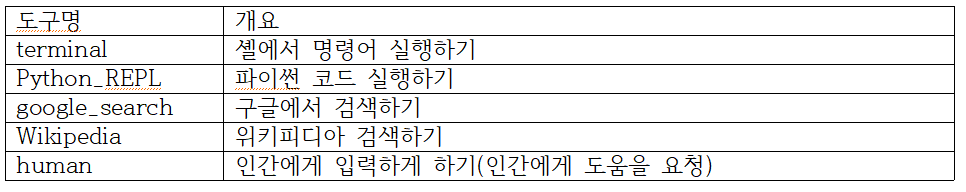<br />
툴의 실체는 매우 간단하며, 단순한 파이썬 함수다. 툴을 직접 만들 수 있습니다.

In [ ]:
tools = [
    search_tool,
    calculator_tool,
    weather_tool,
    terminal_tool
]
라고 하면 agent는 
사용 가능한 Tool이
1. search_tool
2. calculator_tool
3. weather_tool
4. terminal_tool
임을 알고 있게 된다.

### @tool을 작성법
1. 함수 이름은 명확하게 <br />
@tool<br />
def add(a: int, b: int) -> int:<br />
@tool<br />
def web_search(query: str) -> str:<br />
나쁜 예<br />
@tool<br />
def func1(x, y):<br />
<br />
2. 반드시 Docstring 작성:<br />
@tool:<br />
def add(a: int, b: int) -> int::<br />
    """:<br />
    두 정수를 더합니다.:<br />
    계산이 필요한 경우에만 사용합니다.:<br />
    """:<br />
    return a + b:<br />
좋은 Docstring은 무엇을 하는지? 언제 사용하는지? 를 포함<br />
<br />
3. 매개변수 이름도 중요<br />
def translate(text: str):<br />
def get_weather(city: str):<br />
def search(query: str):<br />
나쁜 예<br />
def search(a: str):<br />
<br />
4. 타입 힌트를 반드시 사용
@tool
def add(a: int, b: int) -> int:
@tool
def weather(city: str) -> str:
나쁜 예
def add(a, b):

5. Description은 "언제" 사용해야 하는지<br />
"""<br />
두 정수를 더합니다.<br />
"""<br />
보다는<br />
"""<br />
사용자가 덧셈을 요청했을 때 사용합니다.<br />
"""<br />
가 좋습니다.<br />
<br />
LLM은 "언제 사용하는가"를 더 중요하게 <br />
<br />
6. 반환형도 명확하게<br />
-> int<br />
-> float<br />
-> str<br />
를 적는 것이 좋습니다.<br />
<br />
<br />
### <좋은 tool 예제><br />
@tool<br />
def weather(city: str) -> str:<br />
    """<br />
    도시의 현재 날씨를 조회합니다.<br />
<br />
    사용자가 특정 지역의 날씨를 물어볼 때만 사용합니다.<br />
<br />
    Args:<br />
        city: 도시 이름<br />
<br />
    Returns:<br />
        현재 날씨<br />
    """<br />

In [15]:
from langchain_core.tools import Tool
# 사용자가 정의한 커스텀 함수 및 도구(Tool) 설정
def my_super_func(param):
    return "42"

tools = [
    Tool.from_function(
        func=my_super_func,
        name="The_Answer",
        description="생명, 우주, 그리고 만물에 대한 궁극적인 질문에 대한 답을 구해야 할 때만 사용하세요."
    ),
]

In [ ]:
func : Tool이 호출될 때 실행할 Python 함수.
name : Agent가 Tool을 식별하기 위한 도구 이름
description : Tool의 사용 목적과 용도를 설명합니다. LLM이 어떤 Tool을 선택할지 판단하는 가장 중요한 정보
return_direct : True이면 Tool 실행 결과를 즉시 사용자에게 반환하고 Agent를 종료합니다. False이면 Tool 결과를 바탕으로 계속 추론
args_schema : Tool의 **입력값 형식(매개변수)**을 정의하는 Pydantic 모델입니다. 여러 개의 입력값이나 검증이 필요한 경우 사용
coroutine : 비동기(async) 함수를 Tool로 사용할 때 지정

In [34]:
# 예를 들어 일반 함수가 다음과 같다
def add(a, b):
    return a + b

def sub(a, b):
    return a - b

def mul(a, b):
    return a * b

def div(a, b):
    if b == 0:
        return "0으로 나눌 수 없습니다."
    return a / b

In [35]:
# 이를 Tool로 등록하면
from langchain_core.tools import Tool

tools = [
    Tool.from_function(
        func=add,
        name="add",
        description="두 수를 더할 때만 사용합니다."
    ),
    Tool.from_function(
        func=sub,
        name="sub",
        description="두 수를 뺄 때만 사용합니다."
    ),
    Tool.from_function(
        func=mul,
        name="mul",
        description="두 수를 곱할 때만 사용합니다."
    ),
    Tool.from_function(
        func=div,
        name="div",
        description="두 수를 나눌 때만 사용합니다."
    ),
]

In [ ]:
12와 30을 더해줘.

In [ ]:
Agent의 추론은

In [ ]:
Thought:
덧셈이다.

Action:
add

Action Input:
12,30

15와 27을 더한 결과는 42입니다.


## 3. Toolkits

동시에 사용할 수 있는 몇 가지 툴을 모아놓은 것이 Toolkits다. <<br />
예를 들어, Agents를 사용해 깃허브에 여러 가지 작업을 하고 싶다고 가정해 보자. <br />
이때 다음과 같이 여러 가지 도구를 준비하게 된다.<br />
	* Issue 목록 가져오기<br />
	* Issue 상세보기<br />
	* Issue에 댓글 달기<br />
	* 파일 만들기<br />
	* 파일 불러오기<br />
	* 파일 업데이트하기<br />
	* 파일 삭제하기<br />
랭체인에서 제공하는 Toolkits를 사용하면 이러한 툴을 한꺼번에 준비할 수 있다.<br />
앞서 언급한 깃허브의 조작이라면 GitHubToolkit을 통해 쉽게 툴을 구비할 수 있다.<br />
랭체인에는 이 외에도 다양한 Toolkits가 제공된다.<br />

In [ ]:
# 1. Tool 정의
from langchain_core.tools import tool

@tool
def list_issues() -> str:
    """Issue 목록을 조회합니다."""
    return "Issue #1, Issue #2, Issue #3"

@tool
def get_issue(issue_number: int) -> str:
    """Issue 상세 정보를 조회합니다."""
    return f"Issue {issue_number}의 상세 내용입니다."

@tool
def add_issue_comment(issue_number: int, comment: str) -> str:
    """Issue에 댓글을 등록합니다."""
    return f"Issue {issue_number}에 댓글이 등록되었습니다."

@tool
def create_file(filename: str, content: str) -> str:
    """파일을 생성합니다."""
    return f"{filename} 파일이 생성되었습니다."

@tool
def read_file(filename: str) -> str:
    """파일 내용을 읽습니다."""
    return f"{filename} 파일 내용입니다."

@tool
def update_file(filename: str, content: str) -> str:
    """파일 내용을 수정합니다."""
    return f"{filename} 파일이 수정되었습니다."

@tool
def delete_file(filename: str) -> str:
    """파일을 삭제합니다."""
    return f"{filename} 파일이 삭제되었습니다."

In [ ]:
# 2. Toolkit 생성
from langchain_core.tools import BaseToolkit
from typing import List


class GitHubToolkit(BaseToolkit):
    def get_tools(self) -> List:
        return [
            list_issues,
            get_issue,
            add_issue_comment,
            create_file,
            read_file,
            update_file,
            delete_file,
        ]

In [ ]:
# 3. Toolkit 사용
toolkit = GitHubToolkit()

tools = toolkit.get_tools()

In [ ]:
# 4. Tool 목록 확인
for tool in tools:
    print(tool.name)

In [ ]:
5. Agent에서 사용
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=tools
)

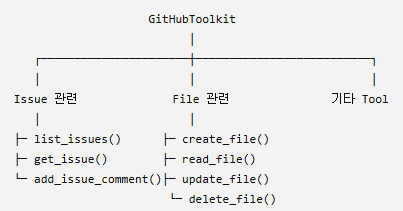

In [ ]:
# 파일 생성, 수정, 삭제가 가능한 프로그램
import os

# 1. Google API Key
os.environ["GOOGLE_API_KEY"] = "your_api_key"

# 2. Tool 정의
from langchain_core.tools import tool


@tool
def create_file(filename: str, content: str) -> str:
    """
    새로운 파일을 생성합니다.
    """
    with open(filename, "w", encoding="utf-8") as f:
        f.write(content)

    return f"{filename} 파일이 생성되었습니다."


@tool
def read_file(filename: str) -> str:
    """
    파일 내용을 읽습니다.
    """
    if not os.path.exists(filename):
        return "파일이 존재하지 않습니다."

    with open(filename, "r", encoding="utf-8") as f:
        return f.read()


@tool
def update_file(filename: str, content: str) -> str:
    """
    파일 내용을 수정합니다.
    """
    if not os.path.exists(filename):
        return "파일이 존재하지 않습니다."

    with open(filename, "w", encoding="utf-8") as f:
        f.write(content)

    return f"{filename} 파일이 수정되었습니다."


@tool
def delete_file(filename: str) -> str:
    """
    파일을 삭제합니다.
    """
    if not os.path.exists(filename):
        return "파일이 존재하지 않습니다."

    os.remove(filename)

    return f"{filename} 파일이 삭제되었습니다."


# 3. Toolkit 정의
from langchain_core.tools import BaseToolkit
from typing import List


class FileToolkit(BaseToolkit):

    def get_tools(self) -> List:
        return [
            create_file,
            read_file,
            update_file,
            delete_file
        ]


# 4. Toolkit 생성
toolkit = FileToolkit()

tools = toolkit.get_tools()


# 5. LLM 생성
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)


# 6. Agent 생성
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=tools
)


# 7. 실행
while True:

    question = input("\n질문 입력(종료: exit) : ")

    if question.lower() == "exit":
        break

    response = agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": question
                }
            ]
        }
    )

    print("\n==============================")
    print("AI 응답")
    print("==============================")

    print(response["messages"][-1].content)

In [ ]:
# 파일 생성 질문 예
memo.txt 파일을 만들고
안녕하세요 Toolkit입니다.
라고 저장해줘.

In [ ]:
# 파일 수정 질문 예
memo.txt 내용을
LangChain Toolkit 예제입니다.
로 수정해줘.

In [ ]:
# 파일 삭제 질문 예
memo.txt 파일을 삭제해줘.

## 4. Function calling
GPT야, 지금 몇 시지?<br />
'GPT에게 다음처럼 알려 줄 수 없다는 답변이 나옵니다.<br />
<br />
사용자: 지금 몇 시지?<br />
AI: 죄송하지만 현재 시간을 알려드릴 수는 없습니다. 사용 중인 기기의 시계를 확인해보시기 바랍니다.<br />
<br />
GPT 같은 언어 모델은 아무리 똑똑해 보이더라도 기본적으로 이전 텍스트를 기반으로 다음에 나올 문장을 예측하는 모델이다.<br/> 
학습을 종료한 시점에 잠들어 있다가 API를 통해 호출될 때마다 깨어나 답변을 해주고 다시 잠드는 사람과 비슷하다.<br />
따라서 현재 시간이 몇 시인지, 밖의 날씨가 어떤지, 최근에 유행하는 음악은 무엇인지 알지 못합니다.<br />
GPT와 대화한 내용을 파일로 저장해 달라고 요청해도 그런 작업은 수행할 수 없습니다.<br />라고 할 것이다.
<br />
펑션 콜링이란?<br />
이러한 GPT의 한계를 극복하기 위해 LLM에서는 펑션 콜링(Function calling) 기능을 제공한다.<br />
펑션 콜링을 활용하면 GPT에게 함수와 그에 관한 설명을 제공하고 상황에 맞는 특정 함수를 호출하도록 할 수 있다.<br />
GPT는 함수 실행 결과를 해석하여 사용자에게 답변을 제공한다.<br />
<br />
LLM에서는 펑션 콜링 기능에 사용할 수 있는 함수를 담은 도구 목록을 딕셔너리 형태로 정의합니다.<br />
예를 들어 사용자가 '지금 몇 시야?'라고 물으면 GPT는 이 도구 목록에서 시간을 확인할 수 있는 도구가 있는지 찾아서 그 도구를 사용해 답변한다.<br />
즉, 도구 목록의 딕셔너리는 GPT 모델이 어떤 도구를 사용할 수 있는지 알려 주는 설명서 역할을 하며, GPT API를 호출할 때 이 도구 목록도 함께 전달됩니다.

In [114]:
from datetime import datetime
import pytz

def get_current_time(timezone: str = 'Asia/Seoul'):
    tz = pytz.timezone(timezone) # 타임존 설정
    now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
    now_timezone = f'{now} {timezone}'
    print(now_timezone)
    return now_timezone


tools = [
    {
        "type": "function",
        "function": {
            "name": "get_current_time",
            "description": "해당 타임존의 날짜와 시간을 반환합니다.",
            "parameters": {
                "type": "object",
                "properties": {
                    'timezone': {
                        'type': 'string',
                        'description': '현재 날짜와 시간을 반환할 타임존을 입력하세요. (예: Asia/Seoul)',
                    },
                },
                "required": ['timezone'],
            },        
        }
    },
]


if __name__ == '__main__':
    get_current_time('America/New_York')

2026-07-12 07:14:06 America/New_York


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os
import json

load_dotenv()

os.environ["GOOGLE_API_KEY"] = "your_api_key"  # 환경 변수에서 API 키 가져오기

# AI 클라이언트의 인스턴스 생성

client = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

def get_ai_response(messages, tools=None): # get_ai_response()함수의 매개변수에 tools를 None으로 추가.
    llm = client
    if tools:
        llm = llm.bind_tools(tools)
    response = llm.invoke(messages)
    return response


messages = [
    {"role": "system", "content": "너는 사용자를 도와주는 상담사야."},  # 초기 시스템 메시지
]

import json

from langchain_core.messages import     HumanMessage,    AIMessage,    ToolMessage

#messages = []

while True:
    user_input = input("사용자 : ")
    if user_input == "exit":
        break
    messages.append(HumanMessage(content=user_input))
    response = get_ai_response(
        messages, # 역할 설명
        tools=tools 
    )
    print(response)
    # Tool 호출 여부 확인
    if response.tool_calls:
        messages.append(response)
        for tool_call in response.tool_calls:
            tool_name = tool_call["name"]
            tool_args = tool_call["args"]
            tool_call_id = tool_call["id"]
            print(tool_name)
            print(tool_args)
            ###################################################
            # Tool 실행
            ###################################################
            if tool_name == "get_current_time":
                result = get_current_time(timezone=tool_args['timezone'])
            else:
                result = "Unknown Tool"
            ###################################################
            # Tool 결과 저장
            ###################################################
            messages.append(
                ToolMessage(
                    content=str(result),
                    tool_call_id=tool_call_id,
                )
            )
        ###################################################
        # Tool 결과를 반영하여 최종 답변 생성
        ###################################################
        response = get_ai_response(
            messages,
            tools=tools
        )
    messages.append(response)
    print("AI :", response.content)

In [ ]:
# gemini-2.5와 function calling 그리고 yfinance를 이용해서 미국주식을 가지고오기

In [81]:
# 1. 설치
!pip install google-genai yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 11.2 MB/s  0:00:00

   ---------------------------------------- 0/4 [peewee]
   ---------------------------------------- 0/4 [peewee]
   ---------------------------------------- 0/4 [peewee]
   ---------------------------------------- 0/4 [peewee]
   ---------- ----------------------------- 1/4 [multitasking]
   -------------------- ------------------- 2/4 [curl_cffi]
   -------------------- ------------------- 2/4 [curl_cffi]
   -------------------- ------------------- 2/4 [curl_cffi]
   ------------------------------ --------- 3/4 [yfinance]
   ------------------------------ --------- 3/4 [yfinance]
   ------------------------------ --------- 3/4 [yfinance]
   ------------------------------ --------- 3/4 [yfinance]
   ------------------------------ --------- 3/4 [yfinance]
   ---------------------------------------- 4/4 [yfinance]



In [82]:
import yfinance as yf

# Microsoft (MSFT)에 대한 Ticker 객체 생성
msft = yf.Ticker("MSFT")

# Ticker 객체에 대한 정보 출력 (.py에서 실행할 때는 print(msft.info)로 사용)
display(msft.info)

{'address1': 'One Microsoft Way',
 'city': 'Redmond',
 'state': 'WA',
 'zip': '98052-6399',
 'country': 'United States',
 'phone': '425 882 8080',
 'website': 'https://www.microsoft.com',
 'industry': 'Software - Infrastructure',
 'industryKey': 'software-infrastructure',
 'industryDisp': 'Software - Infrastructure',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Microsoft Corporation develops and supports software, services, devices, and solutions worldwide. The Productivity and Business Processes segment offers Microsoft 365 commercial, enterprise mobility + security, windows commercial, power BI, exchange, sharepoint, Microsoft teams, security and compliance, and copilot; Microsoft 365 commercial products, such as Windows commercial on-premises and office licensed services; Microsoft 365 consumer products and cloud services, including Microsoft 365 consumer subscriptions, office licensed on-premises, and other consumer serv

In [83]:
hist = msft.history(period="5d") # 5일간의 주가 데이터를 가져옴
display(hist) # 데이터 출력

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-07-06 00:00:00-04:00,387.040009,389.149994,381.220001,386.739990,34224500,0.0,0.0
2026-07-07 00:00:00-04:00,392.489990,395.570007,388.220001,388.839996,29297500,0.0,0.0
2026-07-08 00:00:00-04:00,384.029999,385.309998,381.329987,383.339996,25908300,0.0,0.0
2026-07-09 00:00:00-04:00,374.450012,384.649994,373.350006,384.359985,31083200,0.0,0.0
2026-07-10 00:00:00-04:00,387.799988,391.910004,381.500000,385.100006,24612200,0.0,0.0


In [84]:
msft.recommendations # 추천 정보 출력

,period,strongBuy,buy,hold,sell,strongSell
0,0m,12,41,3,0,0
1,-1m,13,41,3,0,0
2,-2m,12,41,3,0,0
3,-3m,9,43,3,0,0


In [99]:
# 2. yfinance 함수 작성
import yfinance as yf


def get_stock_price(symbol: str):
    """
    미국 주식 현재 가격 조회
    """

    ticker = yf.Ticker(symbol)

    info = ticker.fast_info

    return {
        "symbol": symbol,
        "price": info.get("lastPrice"),
        "currency": info.get("currency"),
        "exchange": info.get("exchange"),
    }

In [100]:
print(get_stock_price("AAPL"))

{'symbol': 'AAPL', 'price': 315.32000732421875, 'currency': 'USD', 'exchange': 'NMS'}


In [101]:
# 3. Function Declaration
# Gemini는 Tool을 JSON Schema 형태로 정의한다.
from google.genai import types

stock_tool = types.FunctionDeclaration(
    name="get_stock_price",
    description="미국 주식의 현재 가격을 조회한다.",
    parameters={
        "type": "object",
        "properties": {
            "symbol": {
                "type": "string",
                "description": "주식 티커(AAPL, TSLA, NVDA 등)"
            }
        },
        "required": ["symbol"]
    }
)

In [102]:
# tool 등록
tool = types.Tool(
    function_declarations=[stock_tool]
)

In [103]:
# 4. LLM 생성
from google import genai
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"  # 환경 변수에서 API 키 가져오기

client = genai.Client(
    api_key=os.environ["GOOGLE_API_KEY"]
)

In [108]:
# 5. 첫 번째 요청
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="테슬라 현재 주가 알려줘",
    config=types.GenerateContentConfig(
        tools=[tool]
    )
)

In [109]:
# 6. Function 실행
function_call = response.candidates[0].content.parts[0].function_call

print(function_call.name)
print(function_call.args)

get_stock_price
{'symbol': 'TSLA'}


In [110]:
result = get_stock_price(
    function_call.args["symbol"]
)

print(result['price'])

407.760009765625


Function Calling은 LLM이 사용자의 요청을 해결하기 위해 필요한 외부 함수(도구)를 선택하고, 해당 함수의 이름과 입력값을 구조화된 형태(JSON 등)로 생성하여 실행 요청을 전달하는 메커니즘이다.<br />
<br />
Function Calling은 LLM이 "어떤 함수를 호출해야 하는지"와 "어떤 인자를 전달해야 하는지"를 구조화된 형태로 결정하는 기능<br />

In [ ]:
# 외부 코드 (실제 실행 부분) : 외부 시스템 (LLM 밖에서 실행되는 코드)
def get_weather(city):
    data = {
        "Seoul": "맑음 25도",
        "Busan": "흐림 22도",
        "Jeju": "비 20도"
    }
    return data.get(city, "정보 없음")

In [ ]:
# LLM이 준 결과
llm_output = '''
{
  "function": "get_weather",
  "arguments": {
    "city": "Seoul"
  }
}
'''

Function Calling의 목적
1. LLM의 한계를 보완 (실시간 데이터, DB 접근 불가)
2. 외부 시스템과 연결
3. 실행과 판단의 분리
3. AI 기능 확장

In [ ]:
import json

# 1. 실제 실행될 함수 (Tool 역할)
def get_weather(city: str):
    weather_db = {
        "Seoul": "맑음, 12도",
        "Busan": "흐림, 15도",
        "Tokyo": "비, 10도"
    }
    return weather_db.get(city, "정보 없음")


# 2. LLM이 생성했다고 가정한 Function Calling 결과
llm_response = {
    "name": "get_weather",
    "arguments": {
        "city": "Seoul"
    }
}

# 3. Function Calling 실행 처리기 (핵심 구조)
def run_function_call(call):
    func_name = call["name"]
    args = call["arguments"]

    if func_name == "get_weather":
        result = get_weather(**args)
        return result

    return "Unknown function"


# 4. 실행
result = run_function_call(llm_response)

print("함수 실행 결과:", result)

In [55]:
# Function Calling을 사용한 전체 예제

In [62]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """
    두 정수를 더합니다.
    """
    return a + b

In [63]:
# 1단계. LLM에 Tool 등록
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

llm_with_tools = llm.bind_tools([add])

In [64]:
# 2단계. 질문 : Gemma3:4b는 사용할 수 없음
from langchain_core.messages import HumanMessage

response = llm_with_tools.invoke(
    [
        HumanMessage("12345와 67890을 더해줘.")
    ]
)   

# 여기서 아직 Tool은 실행되지 않습니다.
# LLM은 다음과 같은 응답을 생성
# content=""   : 답을 만든 것이 아니라 "add Tool을 호출하세요."라고 말한 것이다.

# tool_calls=[
#     {
#         "name":"add",
#         "args":{
#             "a":12345,
#             "b":67890
#         }
#     }
# ]

In [65]:
# 3단계. Tool 실행
for tool_call in response.tool_calls:
    print(tool_call)  # JSON형태로 출력됩을 알 수 있음

{'name': 'add', 'args': {'a': 12345, 'b': 67890}, 'id': 'dc639c37-e3fe-41e3-b5e2-135ac932f4ce', 'type': 'tool_call'}


In [66]:
result = add.invoke(tool_call["args"])
print(result)

80235


In [ ]:
# 4단계. Tool 결과를 다시 LLM에게 전달
from langchain_core.messages import ToolMessage

messages = [
    HumanMessage("98765432와 12345678을 더해줘."),
    response,
    ToolMessage(
        content=str(result),
        tool_call_id=response.tool_calls[0]["id"]
    )
]

answer = llm_with_tools.invoke(messages)

print(answer.content)

In [ ]:
# 1. Tool 만들기
from langchain_core.tools import tool

@tool
def get_order(order_id: str) -> dict:
    """
    주문번호로 주문 정보를 조회합니다.

    Args:
        order_id: 주문번호

    Returns:
        주문 정보
    """

    fake_db = {
        "20260712001": {
            "customer": "홍길동",
            "product": "LG Gram Pro",
            "status": "배송중",
            "invoice": "1234567890"
        },
        "20260712002": {
            "customer": "김철수",
            "product": "Galaxy S26",
            "status": "배송완료",
            "invoice": "9876543210"
        }
    }

    return fake_db.get(
        order_id,
        {"error": "주문이 존재하지 않습니다."}
    )


In [ ]:
# 2. LLM
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [ ]:
# 3. Tool 등록
llm_with_tools = llm.bind_tools(
    [
        get_order
    ]
)

In [ ]:
# 질문
from langchain_core.messages import HumanMessage

response = llm_with_tools.invoke(
    [
        HumanMessage(
            "주문번호 20260712001 배송상태 알려줘."
        )
    ]
)

# Gemini는 내부적으로
#{
#  "tool_calls": [
#    {
#      "name":"get_order",
#      "args":{
#        "order_id":"20260712001"
#      }
#    }
#  ]
#}

In [ ]:
# 5. Tool 실행
tool_call = response.tool_calls[0]

result = get_order.invoke(
    tool_call["args"]
)


In [ ]:
# 6. Tool 결과를 Gemini에게 전달
from langchain_core.messages import ToolMessage

messages = [
    HumanMessage(
        "주문번호 20260712001 배송상태 알려줘."
    ),
    response,
    ToolMessage(
        content=str(result),
        tool_call_id=tool_call["id"]
    )
]

answer = llm_with_tools.invoke(messages)

print(answer.content)

## LangGraph
생성형 AI가 발전하면서 단순히 질문에 답변하는 수준을 넘어, 여러 작업을 스스로 판단하여 수행하는 AI Agent에 대한 관심이 커지고 있다.<br />
여러 AI에이전트를 연결하여 상황에 맞게 다음작업을 하도록 구성할 수 있게 해주는 프레임워크
이는 수학의 그래프 이론에서 따온 개념
그래프 이론에서는 각각의 객체(요소)를 노드로 노드간의 연결을 엣지로 표현
랭그래프는 언어 모델이 처리해야 할 일의 단계와 순서를 그래프로 명확하게 지정하여 앞으로 어떻게 행동하고 판단할디 기준을 제시
예를 들어 사용자가 "GitHub에서 이슈를 조회하고, 필요한 파일을 생성한 후 결과를 요약해 줘."라고 요청하면 AI는 단순히 텍스트를 생성하는 것이 아니라 여러 단계를 거쳐 작업을 수행해야 힙니다.

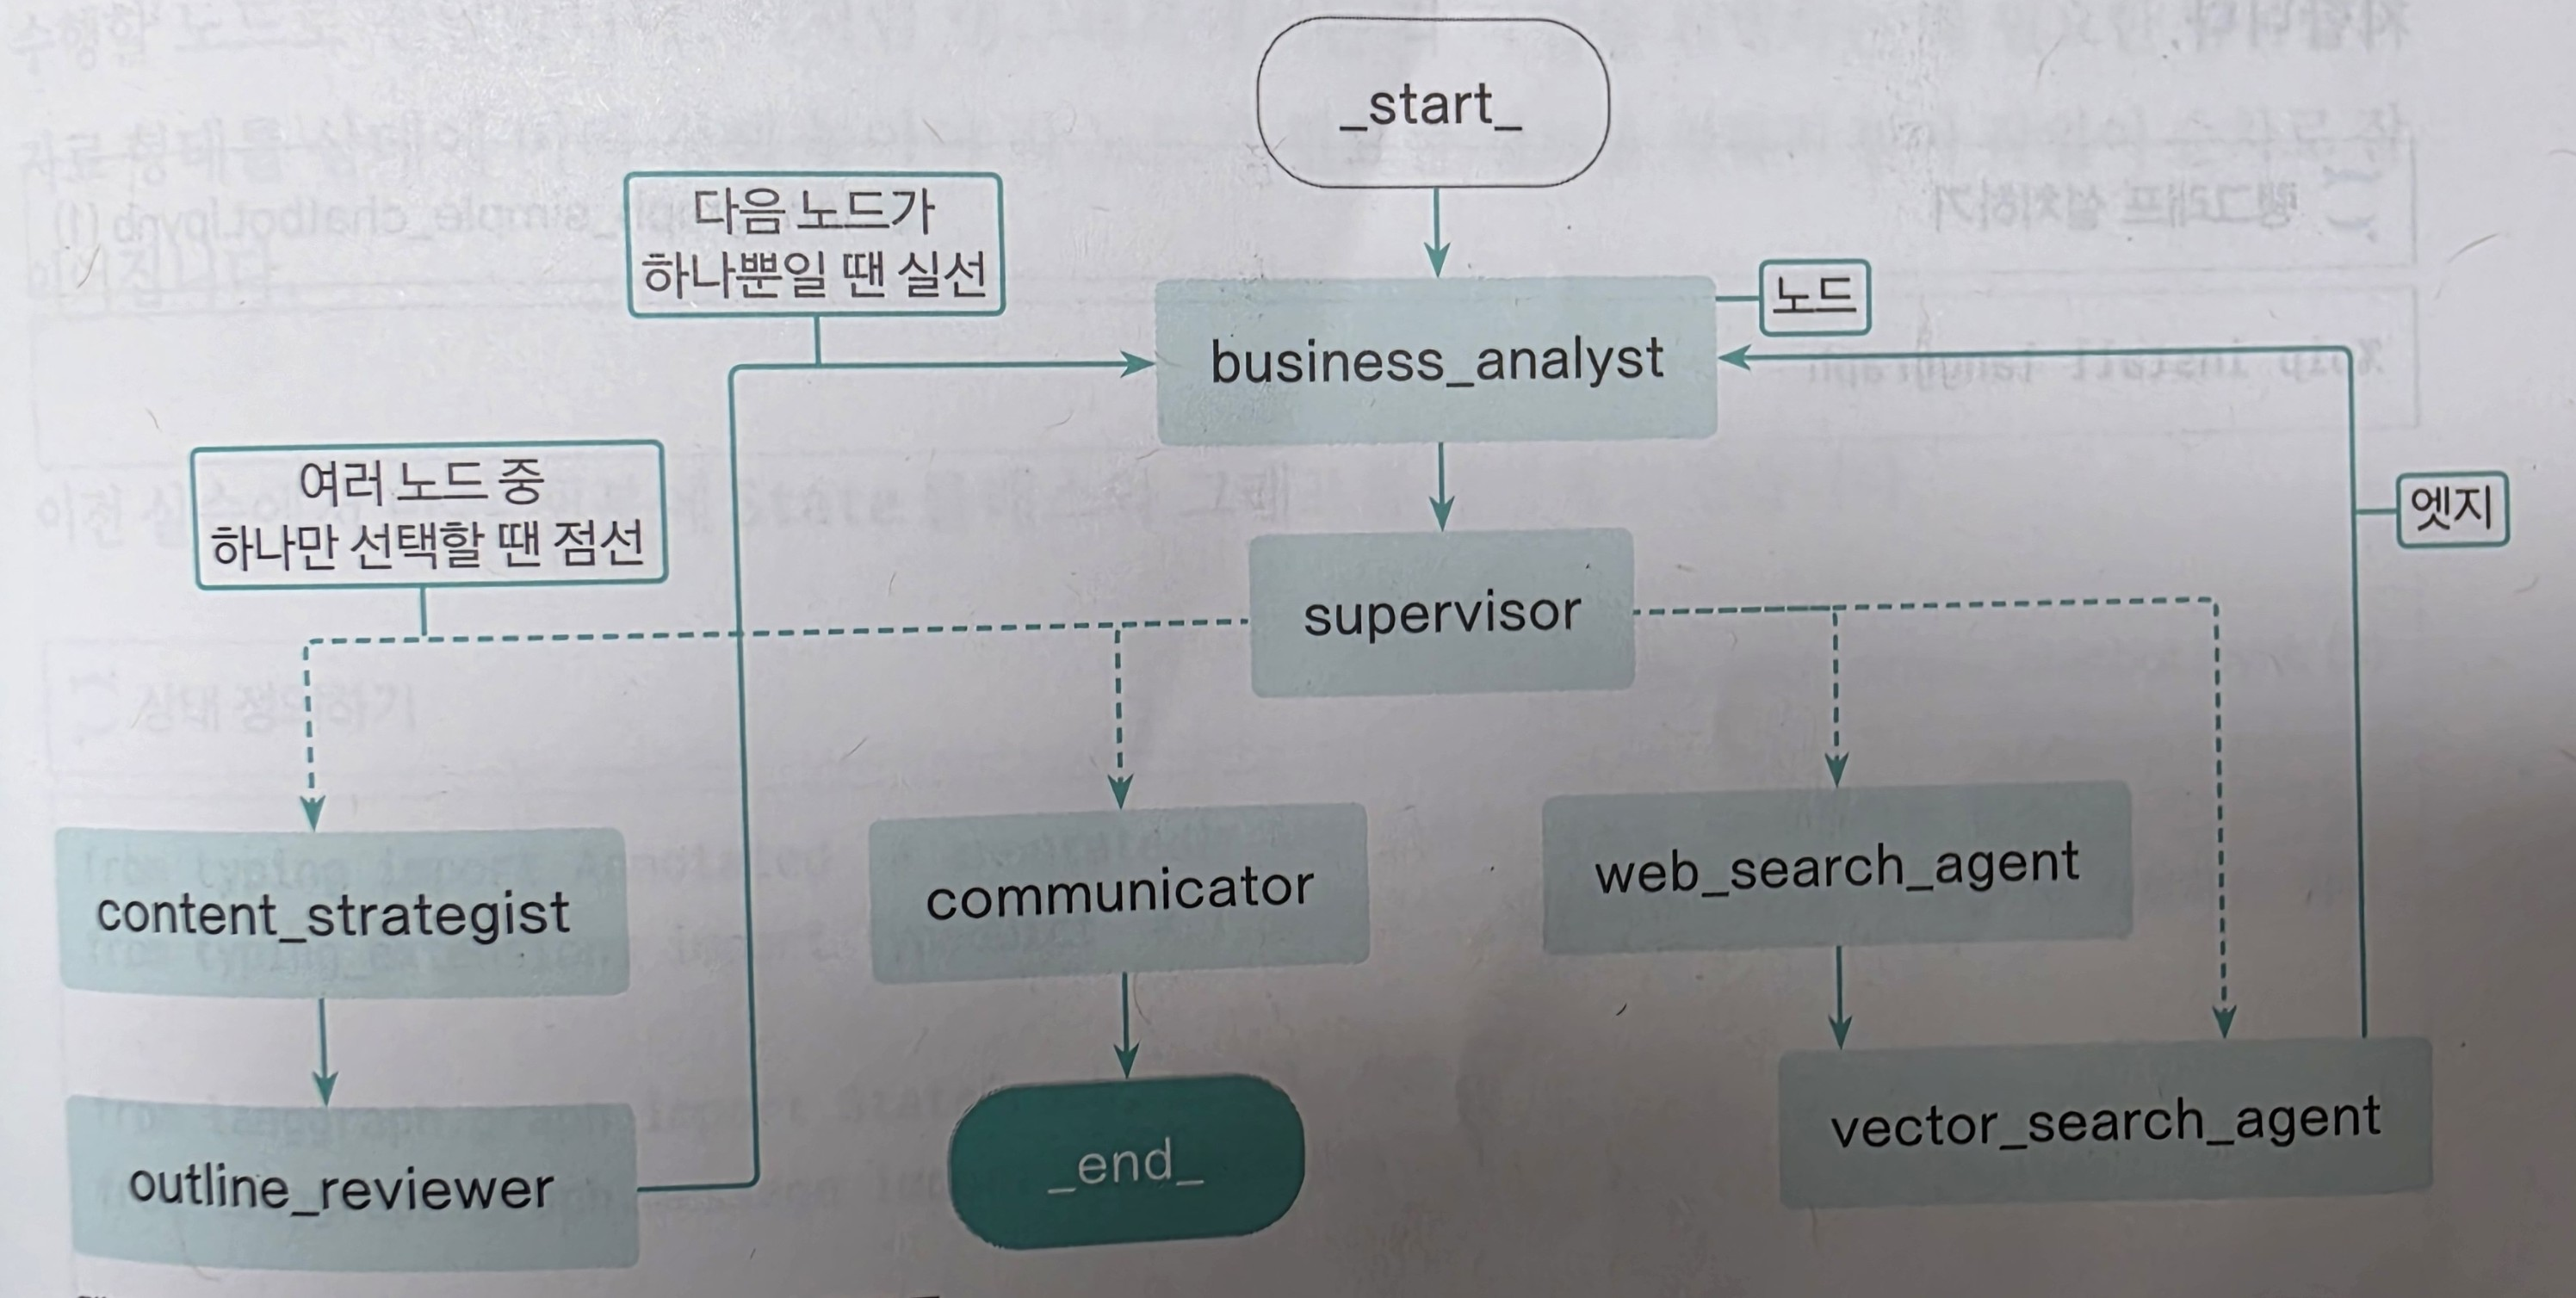

In [ ]:
노드는 하나의 작업이나 단계를 나타냄
네모 상자로 표시한 작업요소가 노드이고, 노드의 연결을 나타내는 화살표는 엣지 

## 랭그래프 핵심 개발 순서

3.그래프 컴파일(Compile)하기:
실행 가능한 상태로 변환.정의한 상태, 노드, 엣지를 StateGraph에 등록한 뒤 .compile() 메서드를 호출
이 과정을 거치면 랭그래프 코드가 하나의 실행 가능한 애플리케이션(Runnable)으로 완성
체커포인터(메모리)를 추가해 이전 대화나 상태를 기억하게 만듬

4.그래프 실행(Invoke/Stream)
애플리케이션 구동.초기 입력값(상태)을 넣고 .invoke()나 .stream()을 호출하여 그래프를 구동
루프(반복문) 구조가 있다면 LLM이 만족스러운 답을 낼 때까지 노드들 사이를 알아서 오가며 작업을 완료

### 랭그래프로 간단한 챗봇 만들기

In [2]:
%pip install langgraph

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 반갑습니다! 😊', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='lc_run--019f4ffa-73ac-74c1-bcb5-0b52baf9438e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 3, 'output_tokens': 33, 'total_tokens': 36, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 28}})

In [ ]:
# 1.상태(State) 정의하기

In [2]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):	# State 클래스는 TypeDict를 사용하여 딕셔너리 형태로 관리됨
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.   
       'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.  
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    
    # State 클래스에는 message라는 변수만 포함되어 있으며, 이 변수는 Annotated를 사용하는 함수로 구성된 리스트 형식
    # add_message함수를 추가. add_message 함수는 langgraph에서 제공하는 함수로 문자열이 주어질 때 이를 추가하는 기능을 한다.
    messages: Annotated[list[str], add_messages]	

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State) # State를 이용해 StateGraph를 만들어 graph_builder라는 변수에 저장

In [ ]:
# 2. 노드 생성하기
각 노드에서 처리한 결과를 상태에서 관리하고, 각 노드를 엣지로 연결하는 그래프 형태로 표현하여 대화나 데이터 흐름을 관리 

In [3]:
def generate(state: State):	# generate함수를 마듬 매개변수는 앞서 정의한 state를 받도록 설정
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
		
    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """ 
    return {"messages": [model.invoke(state["messages"])]}	# state 안에는 message라는 리스트를 담을 수 있는 변수만 포함되어 있음
                                             # 이 노드는 GPT모델에 state["message"]를 전달하여 답변을 받아 온 뒤 그 결과를 딕셔너리 형태로 반환

graph_builder.add_node("generate", generate)	# graph_builder에 generate노드를 추가함, 이때 노드의 이름과 그 해당 함수명을 함께 넣어 줌

In [ ]:
# 엣지 설정
그래프는 노드와 엣지로 구성
노드 앞뒤로 START와 END노드를 지정하고 엣지를 설정한다.

In [4]:
graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)    

graph = graph_builder.compile()

In [ ]:
그래프 구조를 파이썬으로 그려 볼 수 있다.

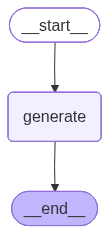

In [5]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception: 
    pass

In [6]:
response = graph.invoke({"messages": ["안녕하세요! 저는 이성용입니다"]})

print(type(response))
response

<class 'dict'>


{'messages': [HumanMessage(content='안녕하세요! 저는 이성용입니다', additional_kwargs={}, response_metadata={}, id='6df41775-37bf-4794-bcc5-6d47f644e26d'),
  AIMessage(content='안녕하세요, 이성용님! 만나서 반갑습니다.\n\n저는 여러분의 질문에 답변하고 정보를 제공하는 AI 어시스턴트입니다. 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='lc_run--019f4ffb-509b-7123-a8d0-b9a16cc5c008-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 1146, 'total_tokens': 1154, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 1110}})]}

In [ ]:
# 이전 대화내용을 이어 나가려면 다음과 같이 .append를 사용하여 원하는 메시지를 추가 한 뒤 graph.invoke()로 다음 문장을 생성

In [7]:
response["messages"].append("제 이름을 아시나요?")
graph.invoke(response)

{'messages': [HumanMessage(content='안녕하세요! 저는 이성용입니다', additional_kwargs={}, response_metadata={}, id='6df41775-37bf-4794-bcc5-6d47f644e26d'),
  AIMessage(content='안녕하세요, 이성용님! 만나서 반갑습니다.\n\n저는 여러분의 질문에 답변하고 정보를 제공하는 AI 어시스턴트입니다. 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='lc_run--019f4ffb-509b-7123-a8d0-b9a16cc5c008-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 1146, 'total_tokens': 1154, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 1110}}),
  HumanMessage(content='제 이름을 아시나요?', additional_kwargs={}, response_metadata={}, id='bacaa6c9-2db0-4bf0-a53a-6d412c955a04'),
  AIMessage(content='네, 이성용님이시죠! 방금 알려주셨어요.\n\n만나서 반갑습니다, 이성용님! 😊', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason

In [ ]:
# 스트림 출력

In [8]:
inputs = {"messages": [("human", "한국과 일본의 관계에 대해 자세히 알려줘")]}
for chunk, _ in graph.stream(inputs, stream_mode="messages"):
    print(chunk.content, end="")

한국과 일본의 관계는 지리적으로 가장 가까운 이웃 국가임에도 불구하고, 복잡하고 다층적인 역사를 바탕으로 협력과 갈등이 교차하는 매우 독특한 관계입니다. 과거사 문제, 영토 분쟁 등 민감한 현안들이 존재하지만, 경제, 문화, 안보 등 다양한 분야에서 상호 의존적이며 협력의 필요성 또한 매우 큽니다.

자세한 내용은 다음과 같습니다.

---

### 1. 역사적 배경: 갈등의 뿌리이자 협력의 시작

*   **고대 및 중세:** 한반도는 일본에 선진 문물(불교, 한자, 유교, 도자기 기술 등)을 전파하며 일본 문화 형성에 지대한 영향을 미쳤습니다. 이는 양국 교류의 긍정적인 측면을 보여줍니다.
*   **임진왜란 (1592-1598):** 도요토미 히데요시의 침략은 한반도에 막대한 피해를 입혔고, 양국 관계에 깊은 상처를 남겼습니다.
*   **근대 및 일제강점기 (1910-1945):** 일본의 강제 병합과 식민 지배는 한일 관계의 가장 큰 갈등의 원천입니다. 이 시기 한국인들은 강제 동원(징용, 징병), 위안부 문제, 문화 말살, 토지 수탈 등 극심한 고통을 겪었습니다. 이 경험은 현재까지도 한국인의 대일 감정에 깊은 영향을 미치고 있습니다.
*   **광복 이후 및 한일 국교정상화 (1965):** 1965년 한일기본조약 및 관련 협정 체결로 양국은 국교를 정상화했습니다. 일본은 한국에 유무상 경제 협력 자금을 제공했고, 한국은 이를 바탕으로 경제 발전에 박차를 가했습니다. 그러나 이 조약이 식민 지배의 불법성과 피해자 개인의 배상 청구권을 완전히 해결했는지에 대한 논란은 현재까지도 이어지고 있습니다.

---

### 2. 주요 갈등 현안

*   **과거사 문제:**
    *   **강제징용 피해자 배상 문제:** 한국 대법원이 일본 기업에 강제징용 피해자 배상을 명령하면서 일본 기업 자산 압류 절차가 진행되자, 일본은 1965년 한일청구권협정으로 모든 문제가 해결되었다는 입장을 고수하며 강력히 반발했습니다. 이는 2019년 일본의 대한국 수출 규제

### 랭그래프의 메모리 기능 활용

In [18]:
!pip show langgraph

Name: langgraph
Version: 1.2.6
Summary: Building stateful, multi-actor applications with LLMs
Home-page: https://docs.langchain.com/oss/python/langgraph/overview
Author: 
Author-email: 
License-Expression: MIT
Location: C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: langchain-core, langgraph-checkpoint, langgraph-prebuilt, langgraph-sdk, pydantic, xxhash
Required-by: langchain


In [ ]:
1. 랭그래프의 메모리를 다루기 전에 기본 챗봇을 만들자

In [3]:
# langgraph_memory.py
# import os
# os.environ["GOOGLE_API_KEY"] = "your_api_key"
# from langchain_google_genai import ChatGoogleGenerativeAI

# model = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
#     temperature=0
# )
from langchain_ollama import ChatOllama
model = ChatOllama(
    model="gemma3:4b",
    temperature=0.7
)
model.invoke('안녕하세요!')

from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.
       'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State)


def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
		
    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """ 
    return {"messages": [model.invoke(state["messages"])]}

graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)    

graph = graph_builder.compile()


from langchain_core.messages import HumanMessage

while True:
    ######## 1 ###########
    user_input = input("You\t:")
    
    if user_input in ["exit", "quit", "q"]:
        break
	############ 파이썬의 input함수를 사용하여 터니널 창에서 사용자가 입력한 내용을 문자열로  받아 user_input 에 저장
    ######## 2 ###########
    for event in graph.stream({ 
        "messages": [HumanMessage(user_input)]}, 
        stream_mode="values"
    ):
    ######## user_input이 유효한 값이라면 graph.stream의 messages에 HumanMessage 클래스를 이용해 리스트 형태로 담아 실행
    ######## stream_mode를 messages가 아니라 values로 설정하여 각 단계의 상태 변화를 스트림 방식으로 가져옴
    ####### 스트림 방식이므로 for 문을 이용해 메시지를 하나씩 가져올 수 있음.
        event["messages"][-1].pretty_print() # vent["messages"]에는 현재 상태의 메시지들이 저장되어 있으므로 가장 마지막 메시지를 
                                             # .pretty_print()로 터미널 창에 출력. 
                                             # .pretty_print()는 객체의 내용을 보기 좋게 출력할 때 사용하며, 출력하는 메시지가 AIMessage인지 
                                             # HumanMessage인지에 따라 터미널 창에 자동으로 구분하여 표시해 줍

    print(f'\n현재 메시지 갯수: {len(event["messages"])}\n-------------------\n')
    # event["messages"]에 저장된 메시지의 개수를 출력하고 while 반복문은 다시 처음으로 돌아감

You	: 난 이숭무야


================================ Human Message =================================

난 이숭무야
================================== Ai Message ==================================

이숭무라는 이름을 들으셨군요. 이숭무는 신라 말의 관료로, 당나라에 잠시 망명한 후 귀환하여 왕건을 도와 고려 건국에 큰 역할을 한 인물입니다.

혹시 이숭무에 대해 더 궁금한 점이 있으신가요? 예를 들어 다음과 같은 질문에 답해드릴 수 있습니다:

*   **이숭무의 생애:** 그의 성장 과정, 당나라 망명, 귀환 과정 등
*   **이숭무의 업적:** 고려 건국에 기여한 부분, 율령 시행 등
*   **이숭무에 대한 평가:** 긍정적인 측면과 부정적인 측면 (특히 '이조십사구설' 관련)

어떤 점이 궁금하신지 좀 더 구체적으로 말씀해주시면 제가 아는 범위 내에서 자세하게 답변해 드리겠습니다.

현재 메시지 갯수: 2
-------------------



You	: 내 이름이 뭐지


================================ Human Message =================================

내 이름이 뭐지
================================== Ai Message ==================================

저는 Google에서 개발한 대규모 언어 모델입니다. 저는 사람처럼 대화하고 질문에 답변하며 다양한 종류의 텍스트를 생성할 수 있습니다. 하지만 저는 개인적인 정보를 가지고 있지 않으며, 제 이름도 없습니다. 

저는 여러분과 소통하기 위해 만들어졌을 뿐입니다! 😊

현재 메시지 갯수: 2
-------------------



You	: exit


In [ ]:
### 코드 수정

In [6]:
# langgraph_memory.py
# import os
# os.environ["GOOGLE_API_KEY"] = "your_api_key"
# from langchain_google_genai import ChatGoogleGenerativeAI

# model = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
#     temperature=0
# )
from langchain_ollama import ChatOllama
model = ChatOllama(
    model="gemma3:4b",
    temperature=0.7
)
model.invoke('안녕하세요!')

from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.
       'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State)


def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
		
    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """ 
    return {"messages": [model.invoke(state["messages"])]}

graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)    

########### 1 #####################
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
#### 랭 그래프에서 제공하는 MemoryServer를 임포트하고 memory라는 이름의 객체로 남듬
########### 2 #####################
config = {"configurable": {"thread_id": "abcd"}}
##### config에서 thread_id를 abcd로 설정. config의 thread_id는 대화방 id. while문 안에서 여러본 입력하더래도 thread_id가 유지되면 기존 대화가 보존
########## 3 #####################
graph = graph_builder.compile(checkpointer=memory)
##### momory 객체는 graph_builder.compile(checkpointer=memory)에서 설정되어 대화 내용을 계속 쌓아 갈 수 있도록 만듬  

#------------ .   
from langchain_core.messages import HumanMessage

while True:
    user_input = input("You\t:")
    
    if user_input in ["exit", "quit", "q"]:
        break
	#②
    for event in graph.stream({
        "messages": [HumanMessage(user_input)]}, 
####### 4 #########################333
        config,
#####  config 추가
        stream_mode="values"
    ):
        event["messages"][-1].pretty_print()

    print(f'\n현재 메시지 갯수: {len(event["messages"])}\n-------------------\n')


You	: 내 이름은 이숭무야


================================ Human Message =================================

내 이름은 이숭무야
================================== Ai Message ==================================

안녕하세요, 이숭무님! 만나서 반갑습니다. 혹시 무엇을 도와드릴까요? 😊

현재 메시지 갯수: 2
-------------------



You	: 내 이름이 뭐지


================================ Human Message =================================

내 이름이 뭐지
================================== Ai Message ==================================

당신의 이름은 이숭무입니다! 😄

현재 메시지 갯수: 4
-------------------



You	: exit


In [21]:
from typing import TypedDict
import requests

from langgraph.graph import StateGraph, START, END

# State
class WeatherState(TypedDict):
    seoul: str
    busan: str


# 외부 API 호출 함수
def get_weather(latitude, longitude):
    url = (
        "https://api.open-meteo.com/v1/forecast"
        f"?latitude={latitude}"
        f"&longitude={longitude}"
        "&current=temperature_2m,weather_code"
    )
    response = requests.get(url)
    data = response.json()
    current = data["current"]
    return f"{current['temperature_2m']}°C"



# Node
def seoul_node(state):

    print("서울 날씨 조회 중...")

    state["seoul"] = get_weather(
        37.5665,
        126.9780
    )

    return state


def busan_node(state):

    print("부산 날씨 조회 중...")

    state["busan"] = get_weather(
        35.1796,
        129.0756
    )

    return state


def print_node(state):

    print("\n===== 현재 날씨 =====")

    print(f"서울 : {state['seoul']}")

    print(f"부산 : {state['busan']}")

    return state


# Graph
builder = StateGraph(WeatherState)

builder.add_node("seoul", seoul_node)
builder.add_node("busan", busan_node)
builder.add_node("print", print_node)

builder.add_edge(START, "seoul")
builder.add_edge("seoul", "busan")
builder.add_edge("busan", "print")
builder.add_edge("print", END)

graph = builder.compile()

graph.invoke({})

서울 날씨 조회 중...
부산 날씨 조회 중...

===== 현재 날씨 =====
서울 : 29.2°C
부산 : 26.4°C


{'seoul': '29.2°C', 'busan': '26.4°C'}

In [ ]:
## 인터넷을 검색 후 기사를 작성하는 챗봇 만들기.

In [33]:
from langchain_ollama import ChatOllama
llm = ChatOllama(
    model="gemma3:4b",
    temperature=0,
)


In [ ]:
랭 그래프의 상태를 선언하고 그 안에 필요한 정보들을 담는 코드를 작성한다.
get_current_time 함수와 웹 검색을 해주는 get_web_search함수를 활용

In [34]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다. 
        주석에 있는 'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State) 

In [35]:
!pip install pytz

In [36]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

import bs4
from langchain_community.document_loaders import WebBaseLoader

# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        # print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr", 
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_current_time, get_web_search]

In [ ]:
# 현재 시간을 얻는 도구 get_current_time 테스트

In [37]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "서울"})

'Asia/Seoul (서울) 현재시각 2026-07-10 13:49:25'

In [ ]:
# 웹 검색도구 get_web_search 테스트

In [38]:
tools[1].invoke({"query": "파이썬", "search_period": "m"})


-------- WEB SEARCH --------
파이썬
m
1. snippet: 2 weeks ago - )은 1991년 네덜란드계 소프트웨어 엔지니어인 귀도 반 로섬이 발표한 고급 프로그래밍 언어로, '인터프리터를 사용하는 객체지향 언어'이자 플랫폼에 독립적인, 동적 타이핑(dynamically typed) 대화형 언어다., title: 파이썬 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/파이썬
2. snippet: 2 days ago - Python is a high-level, general-purpose programming language that emphasizes code readability, simplicity, and ease-of-writing with the use of significant indentation, an extensive ("batteries-included") standard library, and garbage collection. Python supports multiple programming paradigms ..., title: Python (programming language) - Wikipedia, link: https://en.wikipedia.org/wiki/Python_(programming_language)
3. snippet: 3 days ago - Look up Python or python in Wiktionary, the free dictionary. ... Python (painter) (ca. 360–320 BCE), vase painter in Poseidonia · Python of Byzantium (4th-century BCE), orator, diplomat of Philip II of Macedon · Python of Catana, poet who accompanied Alexander the Great · Pyth

'snippet: 2 weeks ago - )은 1991년 네덜란드계 소프트웨어 엔지니어인 귀도 반 로섬이 발표한 고급 프로그래밍 언어로, \'인터프리터를 사용하는 객체지향 언어\'이자 플랫폼에 독립적인, 동적 타이핑(dynamically typed) 대화형 언어다., title: 파이썬 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/파이썬;\nsnippet: 2 days ago - Python is a high-level, general-purpose programming language that emphasizes code readability, simplicity, and ease-of-writing with the use of significant indentation, an extensive ("batteries-included") standard library, and garbage collection. Python supports multiple programming paradigms ..., title: Python (programming language) - Wikipedia, link: https://en.wikipedia.org/wiki/Python_(programming_language);\nsnippet: 3 days ago - Look up Python or python in Wiktionary, the free dictionary. ... Python (painter) (ca. 360–320 BCE), vase painter in Poseidonia · Python of Byzantium (4th-century BCE), orator, diplomat of Philip II of Macedon · Python of Catana, poet who accompanied Alexander the Great · Python Anghelo ..., title: Python - Wikipe

In [ ]:
tools가 어떻게 저장되었는지 확인하기 위해서 다음과 같이 for문을 사용해 하나씩 출력

In [39]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x0000018DA2EF3600>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수.\n\nArgs:\n    query (str): 검색어\n    search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)\n\nReturns:\n    str: 검색 결과' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x0000018DA2EF3CE0>


In [40]:
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """
    # return {"messages": model_with_tools.invoke(state["messages"])}
    return {
        "messages": model.invoke(state["messages"])
    }
graph_builder.add_node("generate", generate)

In [41]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    Attributes:
        tools_by_name (dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
        __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화합니다.
        __call__(inputs: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:    # 
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):    # 
        if messages := inputs.get("messages", []):
            # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옵니다.
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:    # 
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [42]:
def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")
graph = graph_builder.compile()


In [ ]:
실행 결과를 그래프로 그려 보자

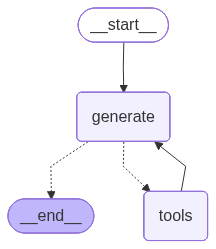

In [43]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [44]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 서울 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

gathered

현재 시간은 2024년 5월 16일 목요일 오후 3시 48분입니다.

AIMessageChunk(content='현재 시간은 2024년 5월 16일 목요일 오후 3시 48분입니다.', additional_kwargs={}, response_metadata={'model': 'gemma3:4b', 'created_at': '2026-07-10T04:50:03.614277Z', 'done': True, 'done_reason': 'stop', 'total_duration': 12349050000, 'load_duration': 9811422700, 'prompt_eval_count': 16, 'prompt_eval_duration': 393483000, 'eval_count': 29, 'eval_duration': 2129841000, 'logprobs': None, 'model_name': 'gemma3:4b', 'model_provider': 'ollama'}, id='lc_run--019f4a5c-4e9e-7c80-9962-eae7f6b28d4f', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 29, 'total_tokens': 45}, tool_call_chunks=[], chunk_position='last')

In [45]:
from langchain_core.messages import AIMessageChunk, SystemMessage

about = "서울월드컵 경기장 잔디 문제"

inputs = [SystemMessage(content=f"""
너는 신문기자이다. 
최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.  

- 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘. 
- 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐. 
- 검색할 리스트를 토대로 재검색을 한다. 
- 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
- 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다. 

더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다. 
    
""")]

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')


## 서울월드컵 경기장 잔디 문제, ‘비용 초과’ 논란 뒤에 숨은 구조적 허점: 솜사탕 공약부터 현실의 고배

**부제:** 2023 한일 월드컵, ‘꿈의 잔디’는커녕 ‘문제 잔디’로 얼룩지다

**리드문:** 2023 FIFA 여자 월드컵 개막 전, 서울월드컵 경기장의 ‘꿈의 잔디’를 구현하겠다고 발표된 모습은 이제 솜사탕 같은 공약에 불과했다. 경기장 잔디 상태 악화로 인해 선수들의 부상 위험이 증가하고, 관중들에게는 최악의 축구 경험을 선사하며, 막대한 비용 초과 논란까지 불러일으켰다. 본 기사는 단순한 ‘잔디 문제’를 넘어 서울월드컵 개최 과정에 깊숙이 자리 잡은 구조적 허점을 심층적으로 분석하고, 책임 소재를 규명하며, 향후 유사 사례 재발 방지를 위한 제도 개선 방향을 제시하고자 한다.

---

### 1. 기사 목차 및 추가 검색 계획

1.  **서론:** 서울월드컵 경기장 잔디 문제의 배경과 심각성 소개 (300자)
    *   검색 내용: ‘서울월드컵 경기장 잔디 문제’, ‘2023 여자 월드컵 경기장 잔디 상태’ 등
2.  **문제 발생 배경:** 잔디 문제의 원인 분석 - 설계 결함, 관리 소홀, 기후 변화 등 (500자)
    *   검색 내용: ‘서울월드컵 경기장 잔디 종류’, ‘경기장 잔디 관리 방법’, ‘잔디 품질 저하 원인’, ‘기후 변화와 잔디’ 등
3.  **선수들의 고통:** 부상 위험 증가 및 경기력 저하 심화 - 선수들의 인터뷰, 의료진 분석 (400자)
    *   검색 내용: ‘서울월드컵 경기장 선수 부상’, ‘경기장 잔디 상태와 부상 위험’, ‘축구선수 부상 관리’, ‘월드컵 선수 인터뷰’ 등
4.  **비용 초과 논란:** 예산 낭비 및 책임 소재 규명 - 관련 자료, 언론 보도 분석 (600자)
    *   검색 내용: ‘서울월드컵 경기장 건설 비용’, ‘경기장 잔디 관리 비용’, ‘예산 초과 발생 원인’, ‘정부 발표 및 언론 보도 비교’ 등
5.  **제도 개선 방안:** 유사 사례 재발 방지를 위한

## 랭그래프를 활용한 멀티에이전트 RAG만들기

## PDF전처리하고 벡터 만들기 

In [1]:
# 사용할 pdf파일 확인
from glob import glob 

for g in glob('./*.pdf'):
    print(g)

.\2040_seoul_plan.pdf
.\OneNYC_2050_Strategic_Plan.pdf
.\과정기반 작물모형을 이용한 웹 기반 밀 재배관리 의사결정 지원시스템 설계 및 구축.pdf


In [2]:
## PDF파일을 텍스트로 읽고 청크 단위로 텍스트를 잘라 리스트에 담기
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

def read_pdf_and_split_text(pdf_path, chunk_size=1000, chunk_overlap=100):
    """
    주어진 PDF 파일을 읽고 텍스트를 분할합니다.
    매개변수:
        pdf_path (str): PDF 파일의 경로.
        chunk_size (int, 선택적): 각 텍스트 청크의 크기. 기본값은 1000입니다.
        chunk_overlap (int, 선택적): 청크 간의 중첩 크기. 기본값은 100입니다.
    반환값:
        list: 분할된 텍스트 청크의 리스트.
    """
    print(f"PDF: {pdf_path} -----------------------------")

    pdf_loader = PyPDFLoader(pdf_path)
    data_from_pdf = pdf_loader.load()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap
    )

    splits = text_splitter.split_documents(data_from_pdf)
    
    print(f"Number of splits: {len(splits)}\n")
    return splits


C:\Users\user\AppData\Local\Temp\ipykernel_25064\3208581020.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [3]:
## vectorstore를 설정하고 청크 처리하기
from langchain_chroma import Chroma
import os
from langchain_huggingface import HuggingFaceEmbeddings

# 임베딩
model_name = "intfloat/multilingual-e5-base"
# GPU가 있다면 "cuda", 없다면 "cpu"
model_kwargs = {'device': 'cpu'}
encode_kwargs = {'normalize_embeddings': True} # 벡터의 정규화 여부
embedding = HuggingFaceEmbeddings(
    model_name = model_name,
    model_kwargs = model_kwargs,
    encode_kwargs = encode_kwargs
)

##### Vectorstore 설정 ####
persist_directory='./chroma_store'

if os.path.exists(persist_directory):
    print("Loading existing Chroma store")
    vectorstore = Chroma(
        persist_directory=persist_directory, 
        embedding_function=embedding
    )
else:
    print("Creating new Chroma store")
    
    vectorstore = None
    for g in glob('./*.pdf'):
        chunks = read_pdf_and_split_text(g)
        # 100개씩 나눠서 저장
        for i in range(0, len(chunks), 100):
            if vectorstore is None:
                vectorstore = Chroma.from_documents(
                    documents=chunks[i:i+100],
                    embedding=embedding,
                    persist_directory=persist_directory
                )
            else:
                vectorstore.add_documents(
                    documents=chunks[i:i+100]
                )


C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Creating new Chroma store
PDF: .\2040_seoul_plan.pdf -----------------------------
Number of splits: 308

PDF: .\OneNYC_2050_Strategic_Plan.pdf -----------------------------
Number of splits: 1023

PDF: .\과정기반 작물모형을 이용한 웹 기반 밀 재배관리 의사결정 지원시스템 설계 및 구축.pdf -----------------------------
Number of splits: 33



In [4]:
# 관련 문서 검색하기 : 벡터 디비가 잘 작동되는지 확인하기 
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

chunks = retriever.invoke("서울 온실가스 저감 계획")

for chunk in chunks:
    print(chunk.metadata)
    print(chunk.page_content)

{'creator': 'Hwp 2020 11.0.0.5178', 'page': 63, 'author': 'SI', 'page_label': '64', 'pdfversion': '1.4', 'creationdate': '2024-12-12T18:16:11+09:00', 'total_pages': 205, 'source': '.\\2040_seoul_plan.pdf', 'moddate': '2024-12-12T18:16:11+09:00', 'producer': 'Hancom PDF 1.3.0.542'}
56제2장 미래상과 목표
6. 미래위기를 준비하는, ‘탄소중립 안전도시 구축’1) 배경전(全) 지구적인 기후변화에 대응하기 위한 대도시 차원의 대응 필요Ÿ서울시 2017년 온실가스 배출량은 46,685천 톤CO2eq로 2005년 배출량에 비해 5.6%(276만 톤CO2eq) 감소하였으며, 서울의 1인당 온실가스 배출량은 4.7CO2eq로 국가의 13.8톤CO2eq에 비해 낮은 수준이다. 또한 2014년 기준 서울의 1인당 온실가스 배출량은 4.5CO2eq로 세계 주요 도시에 비해 낮은 수준을 보인다.7)
[그림 2-26] 세계 주요 도시 1인당 온실가스 배출량   자료: World Bank, 2014Ÿ그럼에도 불구하고, 기후변화 문제는 21세기에 전 지구적으로 가장 위중한 영향을 미칠 것으로 예상되는바, 탄소중립과 기후위기 대응은 국제·국가·도시의 핵심 정책으로 다루어져야 한다.Ÿ파리협정(2015) 이후, 우리나라를 비롯한 미국, 유럽연합 등 세계 136개국이 탄소중립을 선언하였으며, 서울시를 비롯한 뉴욕, 런던 등과 같은 많은 글로벌 도시에서 탄소중립을 시정의 핵심과제로 추진 중이다.Ÿ우리나라는 2020년 ‘한국판 그린뉴딜’을 발표하며 공식적으로 2050 탄소중립을 선언하였으며 서울시 역시 2020년 ‘그린뉴딜 추진을 통한 2050 온실가스 감축 전략’을 발표하고 탄소중립 선언에 따른 부문별 사업을 적극 추진하고 있다.-서울시는 2050년 탄소중립을 목표로 203

In [9]:
from langchain_ollama import ChatOllama
model = ChatOllama(
    model="gemma3:4b",
    temperature=0,
)

In [10]:
# Router 설정
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal # 문자열 리터럴 타입을 지원하는 typing 모듈의 클래스
from pydantic import BaseModel, Field

# Data model
class RouteQuery(BaseModel):
    """사용자 쿼리를 가장 관련성이 높은 데이터 소스로 라우팅합니다."""
    
    datasource: Literal["vectorstore", "casual_talk"] = Field(
        ...,
        description="""
        사용자 질문에 따라 casual_talk 또는 vectorstore로 라우팅합니다.
        - casual_talk: 일상 대화를 위한 데이터 소스. 사용자가 일상적인 질문을 할 때 사용합니다.
        - vectorstore: 사용자 질문에 답하기 위해 RAG로 vectorstore 검색이 필요한 경우 사용합니다.
        """,
    )

In [11]:
# 특정 모델을 structured output (구조화된 출력)과 함께 사용하기 위해 설정
structured_llm_router = model.with_structured_output(RouteQuery)

router_system = """
당신은 사용자의 질문을 vectorstore 또는 casual_talk으로 라우팅하는 전문가입니다.
- vectorstore에는 서울, 뉴욕의 발전계획과 관련된 문서가 포함되어 있습니다. 이 주제에 대한 질문에는 vectorstore를 사용하십시오.
- 사용자의 질문이 일상 대화에 관련된 경우 casual_talk을 사용하십시오.
"""

# 시스템 메시지와 사용자의 질문을 포함하는 프롬프트 템플릿 생성
route_prompt = ChatPromptTemplate.from_messages([
    ("system", router_system),
    ("human", "{question}"),
])

# 라우터 프롬프트와 구조화된 출력 모델을 결합한 객체
question_router = route_prompt | structured_llm_router


In [12]:
print(
    question_router.invoke({
        "question": "서울 온실가스 저감 계획은 무엇인가요?"
    })
)

print(question_router.invoke({"question": "잘 지냈어?"}))

datasource='vectorstore'
datasource='casual_talk'


In [13]:
from langchain_core.prompts import PromptTemplate

class GradeDocuments(BaseModel):
    """검색된 문서가 질문과 관련성 있는지 yes 또는 no로 평가합니다."""

    binary_score: Literal["yes", "no"] = Field(
        description="문서가 질문과 관련이 있는지 여부를 'yes' 또는 'no'로 평가합니다."
    )

structured_llm_grader = model.with_structured_output(GradeDocuments)

In [14]:
grader_prompt = PromptTemplate.from_template("""
당신은 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 평가자입니다. \n 
문서에 사용자 질문과 관련된 키워드 또는 의미가 포함되어 있으면, 해당 문서를 관련성이 있다고 평가하십시오. \n
엄격한 테스트가 필요하지 않습니다. 목표는 잘못된 검색 결과를 걸러내는 것입니다. \n
문서가 질문과 관련이 있는지 여부를 나타내기 위해 'yes' 또는 'no'로 이진 점수를 부여하십시오.
                                             
Retrieved document: \n {document} \n\n 
User question: {question}
""")

retrieval_grader = grader_prompt | structured_llm_grader
question = "서울시 자율주행 관련 계획"
documents = retriever.invoke(question)

for doc in documents:
    print(doc)


page_content='제2장미래상과 목표
제1절 서울의 변화진단제2절 2040 서울의 미래상제3절 2040 서울도시기본계획 7대 목표' metadata={'author': 'SI', 'total_pages': 205, 'creator': 'Hwp 2020 11.0.0.5178', 'page_label': '25', 'source': '.\\2040_seoul_plan.pdf', 'pdfversion': '1.4', 'moddate': '2024-12-12T18:16:11+09:00', 'page': 24, 'creationdate': '2024-12-12T18:16:11+09:00', 'producer': 'Hancom PDF 1.3.0.542'}
page_content='36제2장 미래상과 목표
6) 미래교통수단의 등장과 첨단 인프라 요구 증대자율주행, UAM 등 미래 교통에 공간적 대응방안 마련 필요Ÿ자율주행차량, 전동킥보드 등 교통 기술의 발전에 따라 새로운 교통환경이 조성되고 있음에도 불구하고, 이에 대한 정착 가이드라인이 없어, 위험한 교통 사고가 유발되고 있다.-최근 3년간 서울시에서 발생한 전동킥보드 관련 사고 대다수는 전동 킥보드와 차량 간 충돌 사고Ÿ안전하고 효율적인 기존-신규 교통수단의 조화를 도모하고, 이와 함께 발생할 도시공간구조 변화에 대비하기 위해 통합적인 교통수단 정착 가이드라인이 필요하다.7) 시가지 공간의 포화, 개발가용지의 부족새로운 도시공간에 대한 수요 대응과 성장동력 확보 한계Ÿ서울의 녹지지역을 제외한 대부분의 개발가용지는 고갈된 상태이며, 남은 공간은 주택공급을 위주로 개발하고 있다.-서울시에서 개발제한구역 25%를 제외하면 65%에 해당하는 시가화면적 366㎢ 중 미개발지는 거의 없는 상태Ÿ외연적 팽창이 아닌, 선택과 집중을 통한 콤팩트 시티로의 공간구조 재편을 지향하고 복합 개발을 통해 약해진 도시경쟁력 강화가 필요한 시점이다.8) 늙어가는 서울, 도시 정비의 정체에 따른 환경 악화정비사업 추진동력 저하, 쾌적한 도

In [15]:
filtered_docs = []

for i, doc in enumerate(documents):
    print(f"Document {i + 1}:")
    is_relevant = retrieval_grader.invoke({"question": question, "document": doc.page_content})
    print(is_relevant)
    print(doc.page_content[:200])
    print("=================================\n\n")

    if is_relevant.binary_score == "yes":
        filtered_docs.append(doc)

print(f"Filtered documents: {len(filtered_docs)}")


Document 1:
binary_score='no'
제2장미래상과 목표
제1절 서울의 변화진단제2절 2040 서울의 미래상제3절 2040 서울도시기본계획 7대 목표


Document 2:
binary_score='yes'
36제2장 미래상과 목표
6) 미래교통수단의 등장과 첨단 인프라 요구 증대자율주행, UAM 등 미래 교통에 공간적 대응방안 마련 필요Ÿ자율주행차량, 전동킥보드 등 교통 기술의 발전에 따라 새로운 교통환경이 조성되고 있음에도 불구하고, 이에 대한 정착 가이드라인이 없어, 위험한 교통 사고가 유발되고 있다.-최근 3년간 서울시에서 발생한 전동킥보드 관련 사고 


Document 3:
binary_score='yes'
54제2장 미래상과 목표
5. 기술발전에 선제적 대응, ‘미래교통 인프라 구축’1) 배경미래교통수단 도입에 따른 도시 활동 변화 및 공간구조 재편 대비Ÿ빠르게 진화하는 미래 신 교통수단은 도시공간에 새로운 변화를 일으킬 것이며, 도시 내 이동패턴의 변화를 가져올 것으로 예측된다. 이러한 점을 고려하여 도시 내 다양한 통행행태가 공존하는 포용적인 교통체계 구


Document 4:
binary_score='yes'
셋째, 미래 변화 속 지속가능한 도시의 구축입니다. 디지털 대전환과 기후위기 등 급변하는 시대에 발맞춰 지속가능한 첨단 도시를 구축하기 위한 구체적인 목표를 수립했습니다. 미래 신산업을 육성하고 첨단 미래교통수단의 기반을 마련하는 한편, 자립적인 자원순환체계와 대형재난에 대한 전방위적인 방재체계를 구축하는 등 미래 변화에 대한 도시의 기술 적응력을 강화하고


Document 5:
binary_score='no'
8제1장 개요
광역화, 디지털 전환, 세계화, 팬데믹 등 새로운 여건 변화에 선제적 대응 필요Ÿ2030 서울도시기본계획 수립 이후 서울을 둘러싼 새로운 이슈는 GTX 광역교통망 신설 및 3기 신도시 공급 등 수도권 광역화, 4차 산업혁명과 디지털 전환으로 대변되는 급속한 기술환경 변화, 세계 대도시권 경쟁의 

In [16]:
### Generate
# PromptTemplate을 사용하여 RAG를 위한 프롬프트를 생성합니다.

rag_generate_system = """
너는 사용자의 질문에 대해 주어진 context에 기반하여 답변하는 도시 계획 전문가이다. 
주어진 context는 vectorstore에서 검색된 결과이다. 
주어진 context를 기반으로 사용자의 question에 대해 답변하라.

=================================
question: {question}
context: {context}
"""

# PromptTemplate을 생성하여 question과 context를 포맷팅
rag_prompt = PromptTemplate(
    input_variables=["question", "context"],
    template=rag_generate_system
)

# rag chain
rag_chain = rag_prompt | model 

# 사용자 질문과 검색된 문서를 입력으로 사용하여 RAG를 실행
question = "서울시 자율주행 관련 계획"

rag_chain.invoke({"question": question, "context": filtered_docs})


AIMessage(content='제공된 문맥에 따르면 서울시는 2040년까지 자율주행차량의 전역 운행 환경 구축을 목표로 하고 있습니다. 특히, 2030년에는 간선도로급 이상 도로에서 운영할 수 있는 도로 인프라를 조성하고, 2040년에는 서울 전체에 자율주행차량 운행 환경을 구축하여 수송 분담률 10%를 달성하는 것을 목표로 하고 있습니다. 또한 도심 항공교통 기반 마련 및 터미널 확충, 모빌리티 허브 구축 등 다양한 노력을 통해 자율주행 기술의 성공적인 정착을 지원하고 있습니다.', additional_kwargs={}, response_metadata={'model': 'gemma3:4b', 'created_at': '2026-07-11T09:03:05.8672746Z', 'done': True, 'done_reason': 'stop', 'total_duration': 65613051300, 'load_duration': 546972100, 'prompt_eval_count': 2121, 'prompt_eval_duration': 48999205000, 'eval_count': 146, 'eval_duration': 16018565000, 'logprobs': None, 'model_name': 'gemma3:4b', 'model_provider': 'ollama'}, id='lc_run--019f5069-843c-7743-b364-6247696e9d8d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2121, 'output_tokens': 146, 'total_tokens': 2267})

In [17]:
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    question: str   # 사용자 질문
    generation: str # LLM 생성 결과
    documents: List[str] # 검색된 문서

In [18]:
def route_question(state): 
    """
    사용자 질문을 vectorstore 또는 casual_talk로 라우팅합니다.
    
    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 라우팅된 데이터 소스와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------ROUTE------')
    question = state['question']
    route = question_router.invoke({"question": question})

    
    print(f"---Routing to {route.datasource}---")
    return route.datasource

In [20]:
def retrieve(state): 
    """
    vectorstore에서 질문에 대한 문서를 검색합니다.
    
    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 검색된 문서와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------RETRIEVE------')
    question = state['question']

    # Retrieve documents
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

In [21]:
def grade_documents(state):
    """
    검색된 문서를 평가하여 질문과 관련성이 있는지 확인합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 관련성이 있는 문서와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------GRADE------')
    question = state['question']
    documents = state['documents']
    filtered_docs = []

    for i, doc in enumerate(documents):
        is_relevant = retrieval_grader.invoke({"question": question, "document": doc.page_content})
        if is_relevant.binary_score == "yes":
            filtered_docs.append(doc)
    return {"documents": filtered_docs, "question": question}  

In [22]:
def generate(state):
    """
    LLM을 사용하여 문서와 사용자 질문에 대한 답변을 생성합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): LLM 생성 결과와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------GENERATE------')
    question = state['question']
    documents = state['documents']
    generation = rag_chain.invoke({"question": question, "context": documents})
    return {
        "documents": documents,
        "question": question,
        "generation": generation
    }

In [23]:
def casual_talk(state):
    """
    일상 대화를 위한 답변을 생성합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 일상 대화 결과와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------CASUAL TALK------')
    question = state['question']
    generation = model.invoke(question)
    return {
        "question": question,
        "generation": generation
    }

In [24]:
from langgraph.graph import START, StateGraph, END

workflow = StateGraph(GraphState)

In [25]:
# 노드를 정의 
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("casual_talk", casual_talk)

In [26]:
# graph를 정의
workflow.add_conditional_edges(
    START, 
    route_question,
    {
        "vectorstore": "retrieve",
        "casual_talk": "casual_talk"
    }
)
workflow.add_edge("casual_talk", END)
workflow.add_edge("retrieve", "grade_documents")
workflow.add_edge("grade_documents", "generate")
workflow.add_edge("generate", END)

app = workflow.compile() # workflow를 컴파일

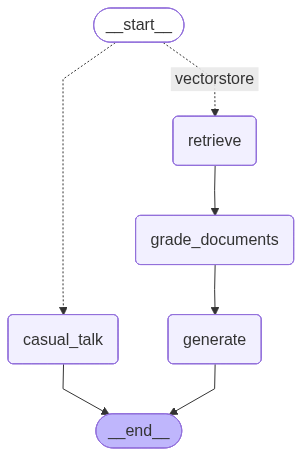

In [27]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    #  실패 시 통과
    pass


In [28]:
inputs = {
    "question": "서울시 자율주행 계획"
}

app.invoke(inputs) # workflow를 실행합니다.

------ROUTE------
---Routing to vectorstore---
------RETRIEVE------
------GRADE------
------GENERATE------


{'question': '서울시 자율주행 계획',
 'generation': AIMessage(content='서울시의 자율주행 계획은 2040년까지 서울 전역에서 자율주행차량 운행 환경을 구축하고, 수송 분담률 10% 달성을 목표로 합니다. 이를 위해 간선도로급 이상 도로에 대한 인프라 조성과 함께 2030년에는 도심 항공교통 기반 마련 및 터미널 확충, 2040년에는 한강, 지천 등 주요 수변 공간 중심으로 광역노선을 확보하는 전략을 추진합니다. 또한 서울 전역에 모빌리티 허브를 구축하여 미래 교통과 기존 교통의 연계를 강화하고, 다양한 기능이 복합적으로 제공되는 지역 거점으로서 역할을 수행할 것입니다.\n', additional_kwargs={}, response_metadata={'model': 'gemma3:4b', 'created_at': '2026-07-11T09:06:27.9338083Z', 'done': True, 'done_reason': 'stop', 'total_duration': 60550820100, 'load_duration': 640041900, 'prompt_eval_count': 1540, 'prompt_eval_duration': 41688118000, 'eval_count': 157, 'eval_duration': 18188823000, 'logprobs': None, 'model_name': 'gemma3:4b', 'model_provider': 'ollama'}, id='lc_run--019f506c-ad55-7c30-b6d7-deb69f2b8bac-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1540, 'output_tokens': 157, 'total_tokens': 1697}),
 'documents': [Document(id='92df123e-a914-4417-8d35-8a357417fe6f', metadata={'page': 

In [29]:
inputs = {
    "question": "잘 지내고 있어?"
}

app.invoke(inputs) # workflow를 실행합니다.

------ROUTE------
---Routing to casual_talk---
------CASUAL TALK------


{'question': '잘 지내고 있어?',
 'generation': AIMessage(content='응, 잘 지내! 너는 어떻게 지내니? 😊 오늘 하루 어땠어? 뭐 하고 있었어?\n', additional_kwargs={}, response_metadata={'model': 'gemma3:4b', 'created_at': '2026-07-11T09:07:05.2123614Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2888571800, 'load_duration': 620637200, 'prompt_eval_count': 16, 'prompt_eval_duration': 358060000, 'eval_count': 27, 'eval_duration': 1898465000, 'logprobs': None, 'model_name': 'gemma3:4b', 'model_provider': 'ollama'}, id='lc_run--019f506e-2033-7731-bfa3-bb9944cfb48e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 27, 'total_tokens': 43})}

In [30]:
inputs = {
    "question": "서울시의 자율주행 차량 관련 계획은 무엇이 있나요?"
}

for msg, meta in app.stream(inputs, stream_mode='messages'):
    print(msg.content, end='')

------ROUTE------
{ "datasource": "vectorstore" }---Routing to vectorstore---
------RETRIEVE------
------GRADE------
{ "binary_score": "yes" }{ "binary_score": "yes" }{ "binary_score": "no" }{ "binary_score": "yes" }{ "binary_score": "yes" }------GENERATE------
서울시의 자율주행 차량 관련 계획은 다음과 같습니다.

*   **2040년까지 서울 전역에 자율주행차량 운행 환경 구축:** 간선도로급 이상 도로에서 운영 가능한 인프라를 조성하고, 2040년까지 서울 전역에서 자율주행차량 운행을 목표로 합니다.
*   **서울형 도심 항공교통 기반 마련 및 터미널 확충:** 김포공항까지 시범 노선을 운영하는 등 상용화 노선을 확보하고, 한강, 지천 등 수변 공간 중심으로 광역 노선을 확장합니다.
*   **모빌리티 허브 구축:** 도심 및 광역 거점에 미래 교통과 기존 교통을 연결하는 시설을 도입하여 다양한 기능(교통, 공공 서비스, 물류, 상업)을 복합적으로 제공하는 지역 거점 모빌리티 허브를 구축합니다.

# 웹과 유튜브 검색을 활용한 챗봇 만들기

In [ ]:
%pip install streamlit
%pip install langchain-ollama
%pip install langchain-community
%pip install duckduckgo-search
%pip install youtube-search
%pip install youtube-transcript-api

In [ ]:
# streamlit_with_web_search.py

import streamlit as st

from langchain_ollama import ChatOllama

from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage,
    ToolMessage,
)

from langchain_core.tools import tool

from datetime import datetime
import pytz

from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper


##############################################################
# LLM
##############################################################

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0,
)


##############################################################
# Tool
##############################################################

@tool
def get_current_time(timezone: str, location: str) -> str:
    """
    현재 시각을 반환한다.
    Args:
        timezone: timezone 이름
        location: 지역명
    """
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        return (
            f"{location} ({timezone}) "
            f"현재 시각은 {now}"
        )
    except Exception:
        return "잘못된 timezone 입니다."
@tool
def get_web_search(query: str,search_period: str) -> str:
    """
    DuckDuckGo 검색
    Args:
        query:
            검색어
        search_period:
            d,w,m,y
    """
    if search_period not in ["d","w","m","y"]:
        search_period = "w"
    wrapper = DuckDuckGoSearchAPIWrapper(
        region="kr-kr",
        time=search_period,
    )
    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        results_separator="\n",
    )
    result = search.invoke(query)
    return result
##############################################################
# Tool Binding
##############################################################
tools = [
    get_current_time,
    get_web_search,
]
tool_dict = {
    "get_current_time":
        get_current_time,
    "get_web_search":
        get_web_search,
}

llm_with_tools = llm.bind_tools(
    tools
)

##############################################################
# AI Response
##############################################################
def get_ai_response(messages):
    response = llm_with_tools.stream(messages)
    gathered = None

    # --------------------------
    # LLM Streaming
    # --------------------------
    for chunk in response:
        if chunk.content:
            yield chunk.content

        if gathered is None:
            gathered = chunk
        else:
            gathered += chunk

    # --------------------------
    # Tool 호출
    # --------------------------
    if gathered is not None and gathered.tool_calls:
        st.session_state.messages.append(gathered)

        for tool_call in gathered.tool_calls:
            selected_tool = tool_dict[tool_call["name"]]

            result = selected_tool.invoke(tool_call["args"])

            tool_message = ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"]
            )

            st.session_state.messages.append(tool_message)

        # Tool 결과를 다시 LLM에게 전달
        yield from get_ai_response(st.session_state.messages)
##############################################################
# Streamlit
##############################################################
st.title(
    "Gemma3 Tool Calling Chatbot"
)
if "messages" not in st.session_state:
    st.session_state.messages = [
        SystemMessage(
            content="""
너는 친절한 AI Assistant이다.
다음 상황에서는 Tool을 사용한다.
- 현재 시간 질문:
  get_current_time 사용
- 최신 정보, 뉴스, 검색 요청:
  get_web_search 사용
Tool 결과를 받은 후 사용자에게 답변한다.
"""
        )
    ]
##############################################################
# 이전 대화 출력
##############################################################
for msg in st.session_state.messages:
    if isinstance(msg, SystemMessage):
        continue
    elif isinstance(msg, HumanMessage):
        st.chat_message(
            "user"
        ).write(msg.content)
    elif isinstance(msg, AIMessage):
        st.chat_message(
            "assistant"
        ).write(msg.content)
    elif isinstance(msg, ToolMessage):
        st.chat_message(
            "tool"
        ).write(msg.content)
##############################################################
# 사용자 입력
##############################################################
if prompt := st.chat_input():
    st.chat_message("user").write(prompt)
    st.session_state.messages.append(
        HumanMessage(
            content=prompt
        )
    )
    response = get_ai_response(st.session_state.messages)
    result = st.chat_message("assistant").write_stream(response)
    st.session_state.messages.append(
        AIMessage(
            content=result
        )
    )

In [ ]:
### 파일명 : streamlit_with_youtube_search.py
# streamlit_with_web_search_youtube.py
import streamlit as st
from langchain_ollama import ChatOllama
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage,
    ToolMessage,
)
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import (DuckDuckGoSearchResults)
from langchain_community.utilities import (DuckDuckGoSearchAPIWrapper)
from youtube_search import YoutubeSearch
from langchain_community.document_loaders import (YoutubeLoader)
from typing import List

##############################################################
# LLM
##############################################################
llm = ChatOllama(
    model="gemma3:4b",
    temperature=0,
)
##############################################################
# Tool 1
# 현재 시간
##############################################################
@tool
def get_current_time(
    timezone: str,
    location: str
) -> str:
    """
    현재 시각을 반환한다.

    Args:
        timezone:
            timezone 이름

        location:
            지역명
    """
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        return (
            f"{location} ({timezone}) "
            f"현재 시각은 {now}"
        )
    except Exception:
        return "잘못된 timezone 입니다."

##############################################################
# Tool 2
# 웹 검색
##############################################################
@tool
def get_web_search(
    query: str,
    search_period: str
) -> str:
    """
    DuckDuckGo 웹 검색을 수행한다.
    Args:
        query:
            검색어
        search_period:
            d,w,m,y
    """
    if search_period not in ["d", "w","m", "y"]:
        search_period = "w"
    wrapper = DuckDuckGoSearchAPIWrapper(
        region="kr-kr",
        time=search_period
    )
    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        results_separator="\n"
    )
    result = search.invoke(query)
    return result

##############################################################
# Tool 3
# YouTube 검색
##############################################################
@tool
def get_youtube_search( query: str) -> List:
    """
    YouTube 검색 후 영상 내용을 반환한다.
    Args:
        query:
            검색어
    """
    print(
        "-------- YOUTUBE SEARCH --------"
    )
    print(query)

    videos = YoutubeSearch(   query, max_results=5).to_dict()
    results = []
    for video in videos:
        video_url = ("https://youtube.com" + video["url_suffix"])
        try:
            loader = YoutubeLoader.from_youtube_url(
                video_url,
                language=["ko", "en"]
            )
            docs = loader.load()
            results.append(
                {
                    "title":video["title"],
                     "url":video_url,
                     "content":docs
                }
            )
        except Exception as e:
            results.append(
                {
                    "title":video["title"],
                    "url":video_url,
                    "content":str(e)
                }
            )
    return results

##############################################################
# Tool Binding
##############################################################
tools = [get_current_time,get_web_search,get_youtube_search]
tool_dict = {
    "get_current_time":get_current_time,
    "get_web_search":get_web_search,
    "get_youtube_search":get_youtube_search
}
llm_with_tools = llm.bind_tools( tools)



##############################################################
# AI Response
##############################################################
def get_ai_response(messages):
    response = llm_with_tools.stream(
        messages
    )
    gathered = None
    for chunk in response:
        if chunk.content:
            yield chunk.content
        if gathered is None:
            gathered = chunk
        else:
            gathered += chunk
    ##########################################################
     # Tool 호출
    ##########################################################
    if gathered is not None and gathered.tool_calls:
        st.session_state.messages.append(
            gathered
        )
        for tool_call in gathered.tool_calls:
            selected_tool = tool_dict[
                tool_call["name"]
            ]
            result = selected_tool.invoke(tool_call["args"])
            tool_message = ToolMessage(content=str(result), tool_call_id=tool_call["id"] )
            st.session_state.messages.append(
                tool_message
            )
        yield from get_ai_response(
            st.session_state.messages
        )

##############################################################
# Streamlit
##############################################################
st.title(
    "Gemma3 Tool Calling Chatbot"
)

if "messages" not in st.session_state:
    st.session_state.messages = [
        SystemMessage(
            content="""
너는 Tool 사용이 가능한 AI Assistant이다.
반드시 다음 규칙을 따른다.
1. 현재 시간 질문
-> get_current_time 사용
2. 최신 뉴스, 최신 정보, 인터넷 검색 요청
-> get_web_search 사용
3. 유튜브 검색 요청
-> get_youtube_search 사용

Tool 실행 후 결과를 분석하여 사용자에게 답변한다.
"""
        )
    ]

##############################################################
# 이전 메시지 출력
##############################################################
for msg in st.session_state.messages:

    if isinstance(msg,SystemMessage):
        continue
    elif isinstance(msg,HumanMessage):
        st.chat_message( "user").write( msg.content )
    elif isinstance( msg, AIMessage ):
        st.chat_message(
            "assistant"
        ).write(
            msg.content
        )
    elif isinstance(msg,ToolMessage):
        st.chat_message( "tool").write( msg.content   )

##############################################################
# 사용자 입력
##############################################################
if prompt := st.chat_input():
    st.chat_message("user").write(prompt)
    st.session_state.messages.append(
        HumanMessage( content=prompt )
    )
    response = get_ai_response( st.session_state.messages)
    result = st.chat_message("assistant").write_stream(response )

    st.session_state.messages.append(
        AIMessage(
            content=result
        )
    )